# Técnicas avanzadas de diseño de software

## Fuzzy Testing

### Vicky, Mateo y Tomy 

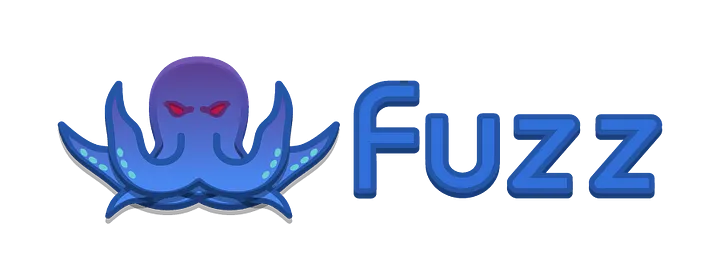

# Borrar esta slide con consideraciones

Usen lo que sea necesario para armar una clase de más o menos 40 minutos alrededor de la arquitectura de esta librería.

Usen la utilidad jupyter rise para hacer esta charla: si instalaron según el readme tienen todo disponible.

Solo este directorio es de ustedes

Consideraciones

- No les doy una fuente por que es brutal de mucho lo que hay
- Tengan en cuenta que a esta altura ya los cumpas ya van a haber visto property based testing asi que Fuzzy con [Hypotesis](https://hypothesis.readthedocs.io/en/latest/) es algo que tienen que dar (les dejo unas slides recicladas aca)
- Enseñen [wFuzz](https://medium.com/@cuncis/fuzzing-made-easy-how-to-use-wfuzz-for-efficient-web-application-testing-d843e5b089bf) (si fuzz tiene algo de algoritmos geneticos, tengan en cuenta que eso lo da el otro grupo
- Recuerden que lo que se da tiene que venir con demo y eso (siempre y cuando no tarde meses en correr)

De aca en adelante son reciclados de clases viejas con algunas ideas

----

## Fuzzy Testing 

- Fuzzy Testing (Fuzzing) es una técnica de pruebas automatizada que proporciona datos inválidos, inesperados o aleatorios como *entrada a un programa* (**caja negra**) para encontrar errores y vulnerabilidades.
- Hay dos tipos principales:
    1. **Tradicional:** Genera entradas aleatorias o semi-aleatorias.
    2. **Basado en cobertura:** Utiliza información de cobertura de código para guiar la generación de entradas.

El fuzzing es valioso en seguridad de software y pruebas de sistemas que procesan entradas complejas o potencialmente maliciosas.

## Funcionamiento del fuzzing basado en cobertura:

1. Instrumenta el código para rastrear la ejecución.
2. Genera entradas iniciales (semillas).
3. Ejecuta el programa y registra la cobertura.
4. Muta las entradas que aumentan la cobertura o exploran nuevos caminos.
5. Repite, favoreciendo mutaciones que descubren nuevo código.

### Desafíos:
- Reproducibilidad de errores debido a la aleatoriedad.
- Posible baja cobertura sin estrategias adecuadas.
- Alto consumo de recursos computacionales.
- Instrumentación puede afectar el rendimiento (en fuzzing basado en cobertura).

# Hypothesis y Fuzzy Testing

Hypothesis tiene una estrecha relación con el fuzzy testing, ofreciendo capacidades que complementan y mejoran las técnicas de fuzzing tradicionales.

Hypothesis permite usar pruebas `@given` como objetivos de fuzzing para fuzzers externos como python-afl, pythonfuzz, o Google's atheris. Esto se logra a través del método `fuzz_one_input` disponible en las pruebas de Hypothesis.

In [11]:
@given(st.text())
def test_foo(s):
    # Tu prueba aquí
    pass

# Crear un objetivo de fuzzing
fuzz_target = test_foo.hypothesis.fuzz_one_input

# Usar el objetivo con un fuzzer
fuzz_target(b"\x00")

b'\x00'

`fuzz_one_input` puede manejar tres escenarios:

1. Input inválido: retorna None
2. Prueba exitosa: retorna un buffer
3. Prueba fallida: añade el caso al ejemplo database de Hypothesis y re-lanza la excepción

Ventajas:
- Reutiliza las pruebas de Hypothesis como objetivos de fuzzing
- Integra los hallazgos del fuzzing con el example database de Hypothesis
- Permite reproducir, minimizar y deduplicar fallos encontrados por fuzzing

Hypothesis también ofrece [HypoFuzz](https://hypofuzz.com/), una herramienta para fuzzing continuo de toda la suite de pruebas, encontrando más bugs sin necesidad de escribir más pruebas.

## HypoFuzz no es basado en coverage, es su propio bicho

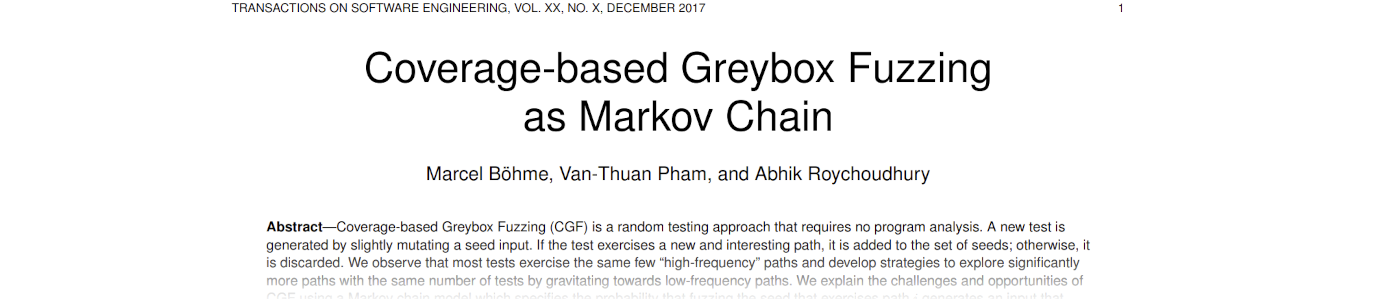

- CGF  no requiere análisis de programa. 
- Funciona mutando ligeramente entradas semilla y reteniéndolas si descubren nuevos caminos de ejecución.

**Características principales:**

- Mutación aleatoria de entradas semilla
- Retención de mutaciones que descubren nuevos caminos
- No requiere análisis de programa previo

> **Desafío:** La mayoría de las pruebas ejercitan los mismos caminos de "alta frecuencia"

**Solución propuesta:**

- Utiliza un modelo de cadena de Markov para representar la probabilidad de transición entre caminos
- Asigna "energía" a cada semilla, inversamente proporcional a la frecuencia de su camino
- Implementa un "power schedule" para controlar la distribución de energía

## HypoFuzz no es basado en coverage, es su propio bicho

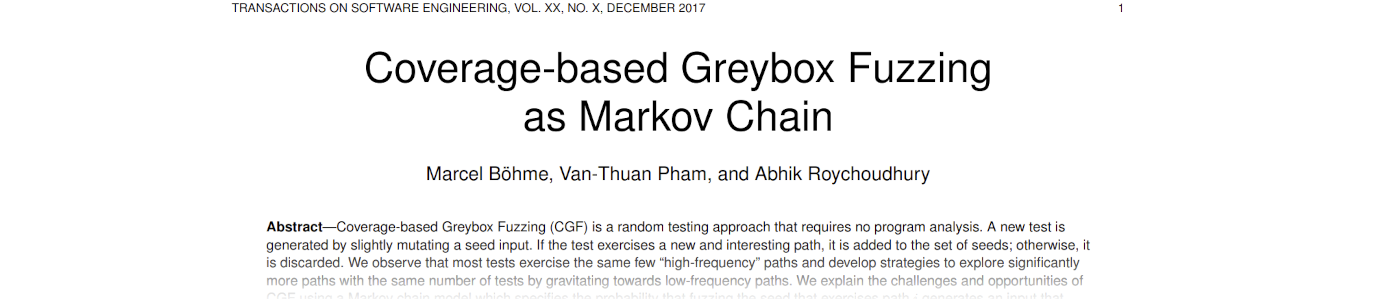

> **Desafío:** La mayoría de las pruebas ejercitan los mismos caminos de "alta frecuencia"

**Solución propuesta:**

- Utiliza un modelo de cadena de Markov para representar la probabilidad de transición entre caminos
- Asigna "energía" a cada semilla, inversamente proporcional a la frecuencia de su camino
- Implementa un "power schedule" para controlar la distribución de energía

## Cerrando

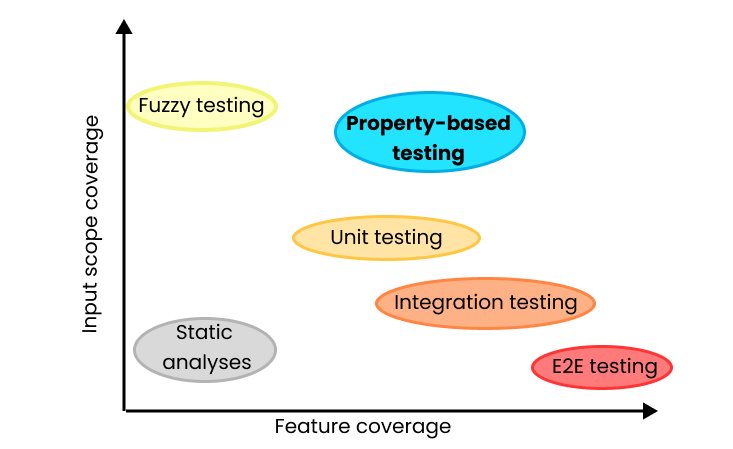